# GA5371 QC Vic/SA Gravity - SGL delivery 010

Author: Mark Dransfield 06 Dec 2022

## Introduction

[This notebook is an example for testing. Notes in [] are later edits for additional explanation.]

It summarises the QC of the DLV010 data delivery by SGL for the Vic/SA Gravity Survey flown for Geoscience Australia. The QC was performed under contract GA5371 in June 2022.

The project is SGL project GeoAus21.AUS and GA project number 5618.

The notebook is organised in line with the Technical Specifictions for the survey. Where data has failed a specification it is reported to SGL for rectification.

DLV010 contains the repeat lines flown during the Caravan phase of acquisition and consists of 4 passes over Devenish (8001), and 4 passes over Otway (8002) lines.

The rest of this first section is setting up the files for analysis, reporting a summary of the delivered data, and plotting a map of the lines flown against the plan.

#### QC Colour Coding

Summary cells are coloured to quickly indicated status against QC. The colours are:

<div class="alert alert-block alert-success">
Delivery passed QC.
<div>

<div class="alert alert-block alert-info">
Delivery was not checked, or has unusual feature but is nevertheless acceptable.
<div>

<div class="alert alert-block alert-warning">
Delivery failed QC and problem has been reported for rectification.
<div>

<div class="alert alert-block alert-danger">
Delivery failed QC and problem might not be readily rectified. This is very rare.
<div>

#### Import required modules, and set filenames for data and plan.

In [1]:
%matplotlib widget
import sys
import importlib as im
import matplotlib.pyplot as plt
import numpy as np 
import xarray as xr
import pooch
import h5py
from pathlib import Path
sys.path.append('/g/data/z67/nfm547/QAQC/AirGravQC_Package')
from src import pointfiles as mhd
from src import qualityAnalysis as qc
from src import whizzPlot as wp
from src import gridfiles as erm

In [2]:
root = r'/g/data/z67/nfm547/QAQC/AirGravQC_Package/examples/AG/DLV010/' 
located_root = root
plan_root = root

# delivered data
d10x = Path(located_root + r'DLV010.xyz')
d10h = d10x.with_suffix('.hdf5')

# Falcon AGG survey line data
f5x = Path(located_root + r'L1033501_106.xyz')
f5h = Path(located_root + r'L1033501_106.hdf5')
f7x = Path(located_root + r'L1033700_94.xyz')
f7h = Path(located_root + r'L1033700_94.hdf5')

# plan
w_plan_file = Path(plan_root + r'GMEV-Planned_Lines_with_Drape.hdf5')

# ground gravity grids
otway_grv_path = Path(root + r'Gravmap2019-grid-grv_cscba.ers')
devenish_grv_path = Path(root + r'Gravmap2019-grid-grv_cscba-IncludesAirborne.ers')

#### Convert data to HDF5

##### Load `xyz` survey data into `hdf` survey file, and set attributes.

[The w_plan_file starts as an HDF5 file because it was made before acquisition started.]

In [3]:
mhd.xyzToHDF(Path(d10x), projectName='Victoria and South Australia Gravity')
block_name = 'DLV010'
mhd.updateProject(d10h, acquirer='SGL', blockID=block_name)

mhd.updateCoordFrame(d10h, lat='LAT', lon='LONG', x='MGA-X', y='MGA-Y', time='FTIME', alt='MGA-Z')
mhd.updateCoordFrame(d10h, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='55')

mhd.updateLineAttributes(d10h, line_type='SGL_GA')

mhd.updateChannelAttributes(d10h, 'ATMCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'B100s-267_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'B100s-267_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'B56s-267_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'B56s-267_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'DEM', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'EOTCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FA100s_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FA100s_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FA56s_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FA56s_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FACOR_GEOID', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FACOR_GRS80', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FTIME', units='s', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'FX', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FY', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'FZ', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'LALT', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'LAT', units='degree', chan_precision=7)
mhd.updateChannelAttributes(d10h, 'LATCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'LONG', units='degree', chan_precision=7)
mhd.updateChannelAttributes(d10h, 'MGA-X', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'MGA-Y', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'MGA-Z', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'MSL-Z', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'RALT', units='m', chan_precision=2)
mhd.updateChannelAttributes(d10h, 'STATCOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'TACOR', units='mGal', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'V_EAST', units='m/s', chan_precision=3)
mhd.updateChannelAttributes(d10h, 'V_NORTH', units='m/s', chan_precision=3)

/

/

/   LINE FLIGHT  YEAR  DOY      FTIME       MGA-X       MGA-Y      MGA-Z      MSL-Z           LAT          LONG    PDOP    VDOP    HDOP   NSATS         DEM        RALT        LALT           FX           FY           FZ       V_EAST      V_NORTH       EOTCOR       LATCOR      STATCOR       ATMCOR  FACOR_GRS80  FACOR_GEOID        TACOR  FA56s_GRS80  FA56s_GEOID FA100s_GRS80 FA100s_GEOID B56s-267_GRS80 B56s-267_GEOID B100s-267_GRS80 B100s-267_GEOID

 Line      8001.00

Found 3 header records
Found 8 lines
Found 38 fields
LINE - precision 2
FLIGHT - precision 0
YEAR - precision 0
DOY - precision 0
FTIME - precision 2
MGA-X - precision 2
MGA-Y - precision 2
MGA-Z - precision 2
MSL-Z - precision 2
LAT - precision 7
LONG - precision 7
PDOP - precision 2
VDOP - precision 2
HDOP - precision 2
NSATS - precision 0
DEM - precision 2
RALT - precision 2
LALT - precision 2
FX - precision 3
FY - precision 3
FZ - precision 3
V_EAST - precision 3
V_NORTH - precision 3
EOTCOR - precision 3
LATCOR -

[This next file is a single line from a different project that happens to coincide in location with a test line, so it is useful for comparison]

In [4]:
mhd.xyzToHDF(Path(f7x), projectName='Otway Gravity')
block_name = 'L1033700'
mhd.updateProject(f7h, acquirer='Xcalibur', blockID=block_name)

mhd.updateCoordFrame(f7h, lat='GNSS_Latitude_GDA94', lon='GNSS_Longitude_GDA94', x='GNSS_Easting_GDA94MGA54', y='GNSS_Northing_GDA94MGA54', alt='Elevation_GNSS_GRS80')
mhd.updateCoordFrame(f7h, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='54')

mhd.updateChannelAttributes(f7h, 'Falc_gD_2p67_SD_Conformed_sGrav_ANGDB09', units='gu', chan_precision=3)
mhd.updateChannelAttributes(f7h, 'GNSS_Latitude_GDA94', units='degree', chan_precision=7)
mhd.updateChannelAttributes(f7h, 'GNSS_Longitude_GDA94', units='degree', chan_precision=7)
mhd.updateChannelAttributes(f7h, 'GNSS_Easting_GDA94MGA54', units='m', chan_precision=2)
mhd.updateChannelAttributes(f7h, 'GNSS_Northing_GDA94MGA54', units='m', chan_precision=2)
mhd.updateChannelAttributes(f7h, 'Elevation_GNSS_GRS80', units='m', chan_precision=2)

/GNSS_Easting_GDA94MGA54 GNSS_Northing_GDA94MGA54 Falc_gD_2p67_SD_Conformed_sGrav_ANGDB09 GNSS_Latitude_GDA94 GNSS_Longitude_GDA94 Elevation_GNSS_GRS80

Line  1033700

Found 1 header records
Found 1 lines
Found 6 fields
GNSS_Easting_GDA94MGA54 - precision 2
GNSS_Northing_GDA94MGA54 - precision 2
Falc_gD_2p67_SD_Conformed_sGrav_ANGDB09 - precision 4
GNSS_Latitude_GDA94 - precision 7
GNSS_Longitude_GDA94 - precision 7
Elevation_GNSS_GRS80 - precision 3
/g/data/z67/nfm547/QAQC/AirGravQC_Package/examples/AG/DLV010/L1033700_94.hdf5
<HDF5 group "/Whizz Version 1.0/Lines/1033700.0" (6 members)> 1


#### Report contents of survey data whizz file, Otway data and planned data.

In [5]:
mhd.reportWhizz(d10h)

Whizz Version 1.0
    Acquirer: SGL
    BlockID: DLV010
    ProjectName: Victoria and South Australia Gravity

Coordinates
    AltitudeChannel: MGA-Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA-X
    YChannel: MGA-Y
8 lines: total distance flown [km] = 393.4

8 lines:
 ['8001.0', '8001.01', '8001.02', '8001.03', '8002.01', '8002.02', '8002.03', '8002.04']

38 channels:
 ['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID', 'B56s-267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID', 'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID', 'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT', 'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z', 'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST', 'V_NORTH', 'YEAR']


In [6]:
mhd.reportWhizz(f7h)

Whizz Version 1.0
    Acquirer: Xcalibur
    BlockID: L1033700
    ProjectName: Otway Gravity

Coordinates
    AltitudeChannel: Elevation_GNSS_GRS80
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: GNSS_Latitude_GDA94
    LongitudeChannel: GNSS_Longitude_GDA94
    Projection: MGA
    UTMZone: 54
    XChannel: GNSS_Easting_GDA94MGA54
    YChannel: GNSS_Northing_GDA94MGA54
1 lines: total distance flown [km] = 119.6

1 lines:
 ['1033700.0']

6 channels:
 ['Elevation_GNSS_GRS80', 'Falc_gD_2p67_SD_Conformed_sGrav_ANGDB09', 'GNSS_Easting_GDA94MGA54', 'GNSS_Latitude_GDA94', 'GNSS_Longitude_GDA94', 'GNSS_Northing_GDA94MGA54']


Report contents of plan whizz File.

In [7]:
mhd.reportWhizz(w_plan_file)

Whizz Version 1.0
    ProjectName: GMEV Planned Drape

Coordinates
    AltitudeChannel: Drape_m
    LatitudeChannel: W84_Latitude_deg
    LongitudeChannel: W84_Longitude_deg
    XChannel: W84_UTM_55S_X_m
    YChannel: W84_UTM_55S_Y_m
1025 lines: total distance flown [km] = 187,256.8

1025 lines:
 ['2001.0', '2003.0', '2005.0', '2007.0', '2009.0', '201.0', '2011.0', '2013.0', '2015.0', '2017.0', '2019.0', '202.0', '2021.0', '2023.0', '2025.0', '2027.0', '2029.0', '203.0', '2031.0', '2033.0', '2035.0', '2037.0', '2039.0', '204.0', '2041.0', '2043.0', '2045.0', '2047.0', '2049.0', '205.0', '2051.0', '2053.0', '2055.0', '2057.0', '2059.0', '206.0', '2061.0', '2063.0', '2065.0', '2067.0', '2069.0', '207.0', '2071.0', '2073.0', '2075.0', '2077.0', '2079.0', '208.0', '2081.0', '2083.0', '2085.0', '2087.0', '2089.0', '209.0', '2091.0', '2093.0', '2095.0', '2097.0', '2099.0', '210.0', '2101.0', '2103.0', '2105.0', '2107.0', '2109.0', '211.0', '2111.0', '2113.0', '2115.0', '2117.0', '2119.0', '2

#### Make a lines map.

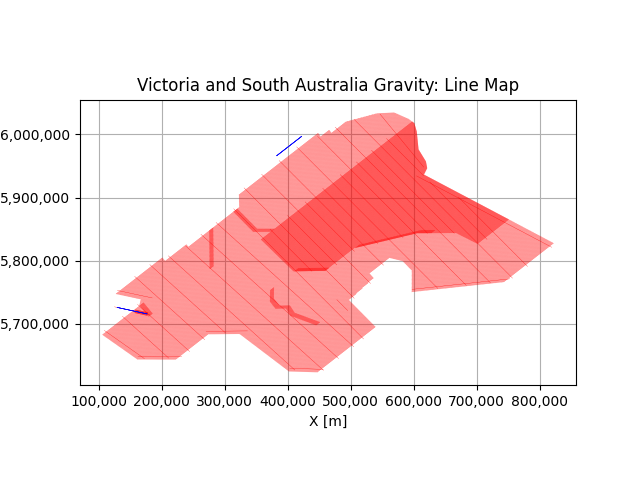

In [8]:
wp.linesMap([d10h], whizzPlanFile=w_plan_file)

[The red lines are the planned lines. The two blue lines are the measured (repeat line) lines in DLV010. The SW one coinclides with L1033700 in f7h.]

<div class="alert alert-block alert-success">
Data imported successfully.
<div>

## Quality checks

The following sections describe the quality checks on the data. The data were delivered in XYZ format, an ASCII text fixed-width column format, separated by survey line number. All data were provided to a decimal precision better than nominal accuracy. Some of the following sections refer to an “aspect” and this means an aspect described in the survey contract.

Quality checks are reported by specification and are marked “pass” if all data passed, “accept” if the data were accepted despite minor deviations from specification or if the deviations were for safety reasons, “fail” if one or more lines require re-flying, or “NA” if the specification is not applicable to the delivered data.

### Survey Data

See the report [QC_DLV001_011.pdf] for details.

#### Test lines repeatability
<div class="alert alert-block alert-info">
PASS
<div>

[Comparing data from DLV010 with that from the Otway project along the same location.]

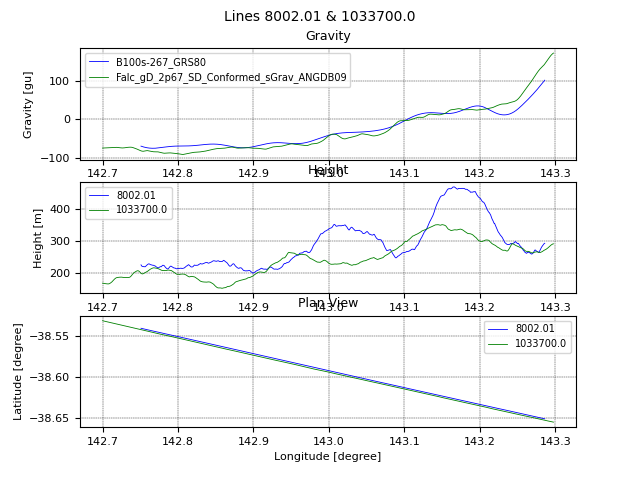

In [9]:
%matplotlib widget
wp.plotWsLineChannel(d10h, '8002.01', 'B100s-267_GRS80', f7h, '1033700.0',
                     'Falc_gD_2p67_SD_Conformed_sGrav_ANGDB09',  x1='LONG', x2='GNSS_Longitude_GDA94',
                     y1='LAT', y2='GNSS_Latitude_GDA94', xOffset=False)

Comparing repeat lines at Otway test line (top) and Devenish test line (bottom).]

4 lines analsyed, each with 1653 samples.
Line 8002.01: stdev(B100s-267_GRS80) = 0.35 mGal
Line 8002.02: stdev(B100s-267_GRS80) = 0.35 mGal
Line 8002.03: stdev(B100s-267_GRS80) = 0.29 mGal
Line 8002.04: stdev(B100s-267_GRS80) = 0.34 mGal
Line 8002.01: stdev(MGA-Z) = 3.3 m
Line 8002.02: stdev(MGA-Z) = 2.6 m
Line 8002.03: stdev(MGA-Z) = 3.1 m
Line 8002.04: stdev(MGA-Z) = 4.5 m


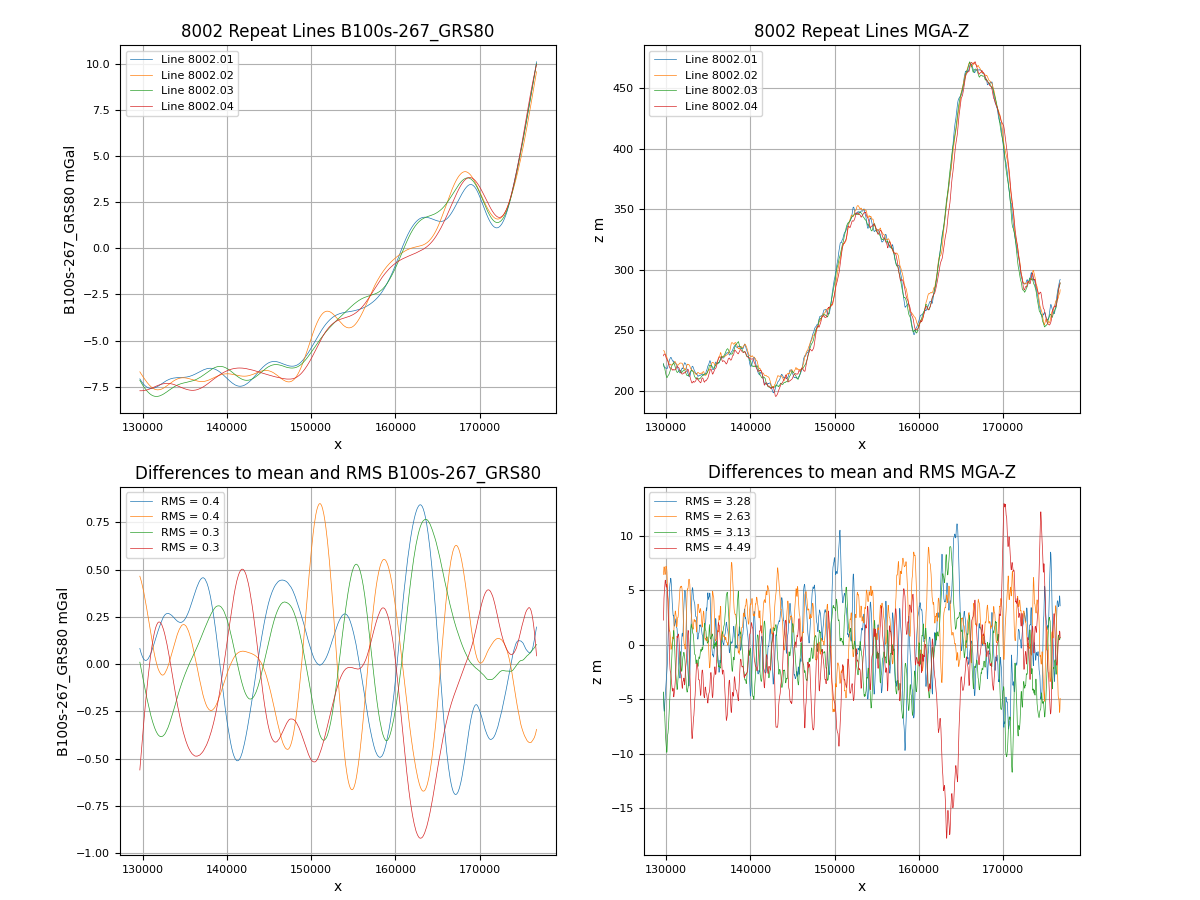

In [10]:
qc.checkRepeatLines(d10h, 'B100s-267_GRS80', ['8002.01', '8002.02', '8002.03', '8002.04'], xOffset=False)

4 lines analsyed, each with 1767 samples.
Line 8001.0: stdev(B100s-267_GRS80) = 0.29 mGal
Line 8001.01: stdev(B100s-267_GRS80) = 0.31 mGal
Line 8001.02: stdev(B100s-267_GRS80) = 0.36 mGal
Line 8001.03: stdev(B100s-267_GRS80) = 0.35 mGal
Line 8001.0: stdev(MGA-Z) = 2.9 m
Line 8001.01: stdev(MGA-Z) = 3.0 m
Line 8001.02: stdev(MGA-Z) = 3.1 m
Line 8001.03: stdev(MGA-Z) = 3.0 m


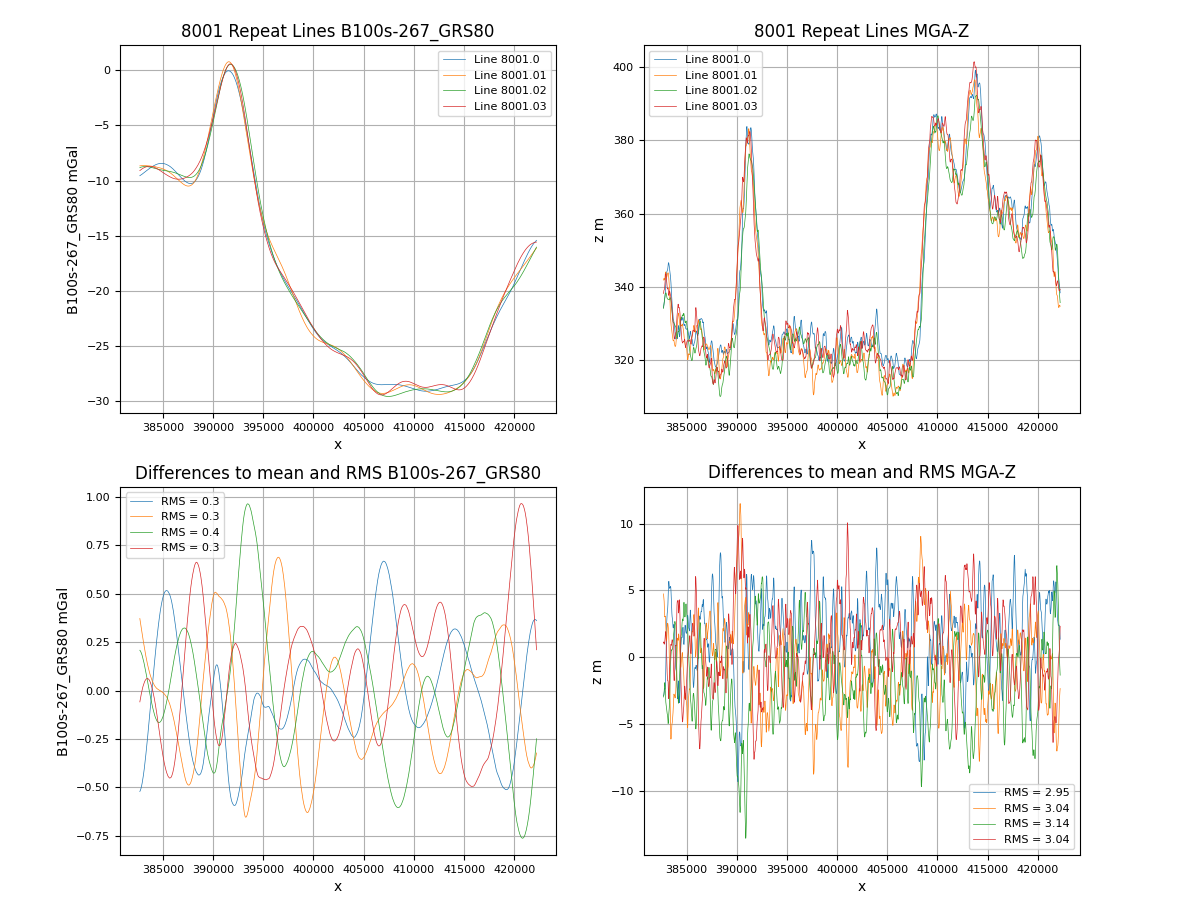

In [11]:
qc.checkRepeatLines(d10h, 'B100s-267_GRS80', ['8001.0', '8001.01', '8001.02', '8001.03'], xOffset=False)

#### Test lines ground comparison
<div class="alert alert-block alert-info">
PASS
<div>

Go to GADDS and download a copy of Gravmap2019-grid-grv_cscba as an ERS file for the area. Do the comparison. Take care to have matching UTM zones.

32 bit precision

Grid file read for channel  Gravmap2019-grid-grv_cscba
  SW Corner =  5637482.5 86107.5   NE Corner =  5795902.5 276122.5 . Spacings =  445.0 445.0
Line 8002.03
  North min, max  5715393.54 5725634.41   East min, max  129639.28 176777.78
Stdev(diff) = 36.8


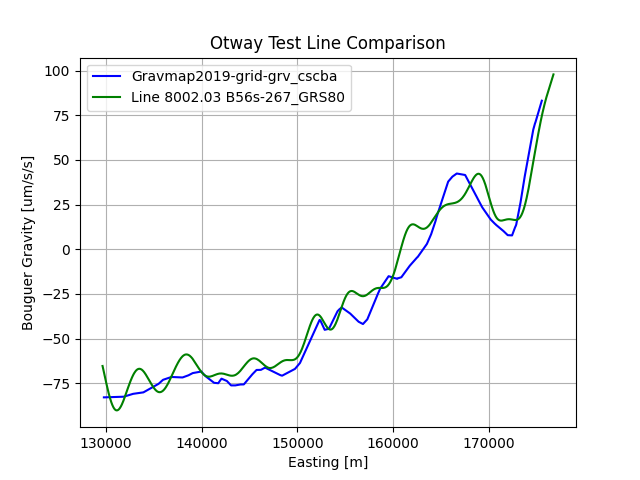

In [12]:
qc.diffGroundGrid(d10h, 'B56s-267_GRS80', '8002.03', otway_grv_path, plot_title='Otway Test Line Comparison')

32 bit precision

Grid file read for channel  Gravmap2019-grid-grv_cscba-IncludesAirborne
  SW Corner =  5953432.5 370462.5   NE Corner =  6000157.5 438102.5 . Spacings =  445.0 445.0
Line 8001.03
  North min, max  5966306.73 5997056.81   East min, max  382678.01 422228.56
Stdev(diff) = 106.9


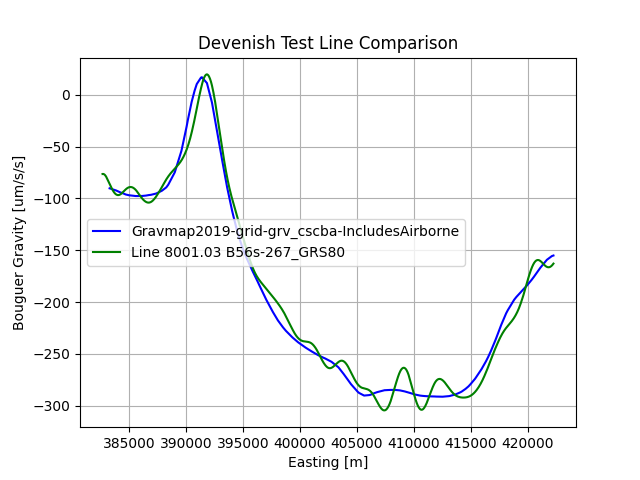

In [13]:
qc.diffGroundGrid(d10h, 'B56s-267_GRS80', '8001.03', devenish_grv_path, plot_title='Devenish Test Line Comparison')

#### Test lines on ground
<div class="alert alert-block alert-success">
PASS
<div>

[Here I just want to look at the ground gravity quality and sample spacing to judge its reliability for comparison with the airborne data (test line plotted as blue line).]

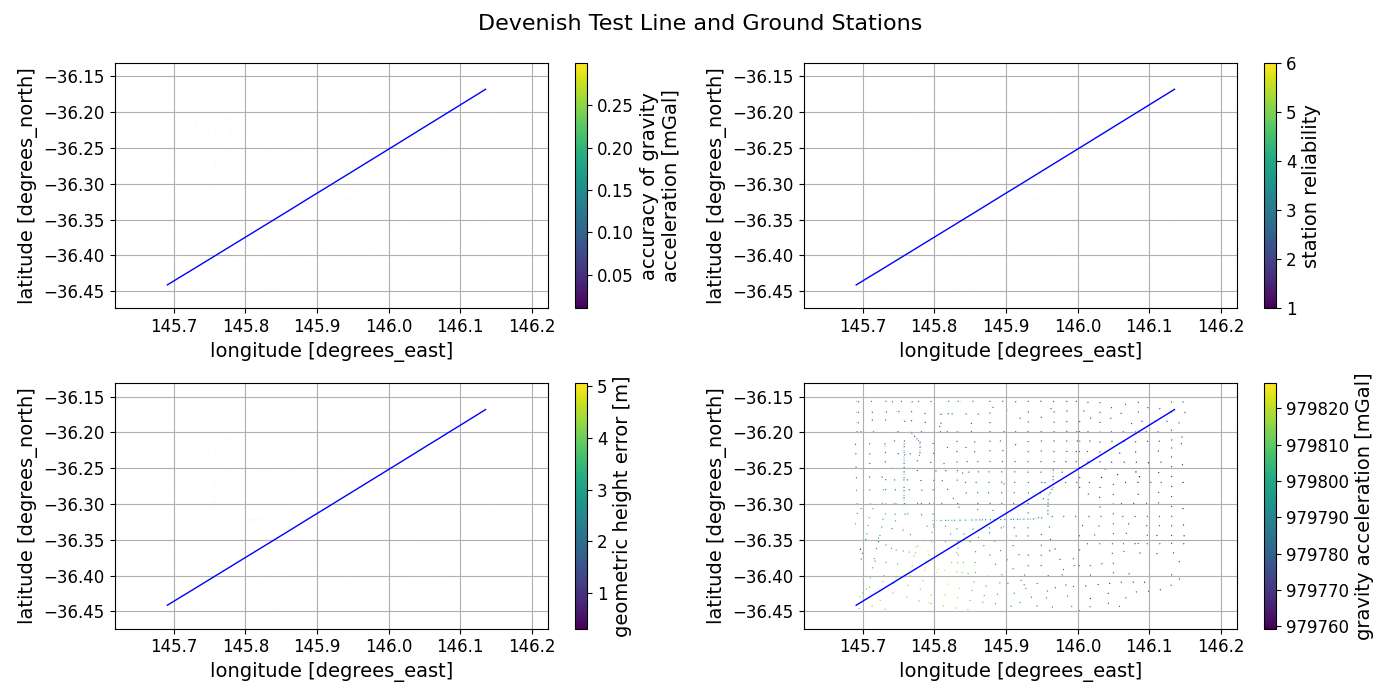

In [14]:
wp.plotLinesOnGroundStns(d10h, '8001.03', minlon=145.69, maxlon=146.15, minlat=-36.45, maxlat=-36.15, fig_title='Devenish Test Line and Ground Stations')

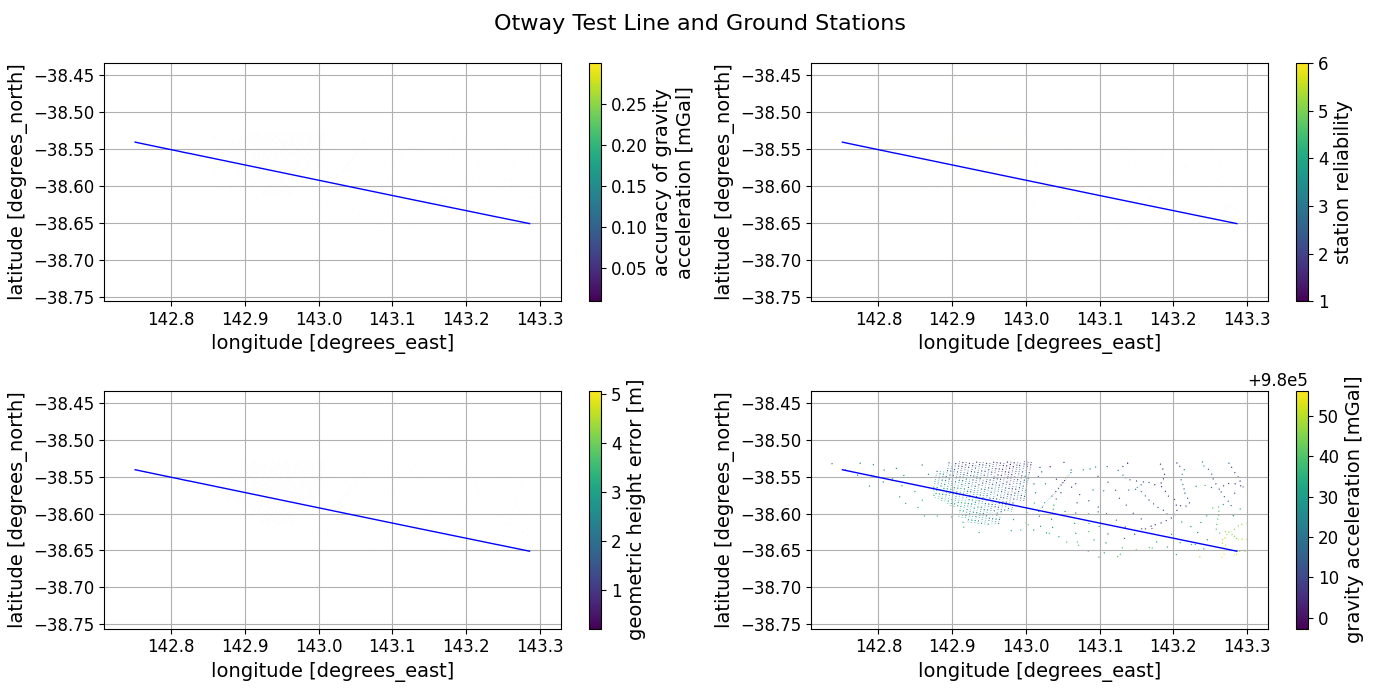

In [15]:
wp.plotLinesOnGroundStns(d10h, '8002.03', minlon=142.7, maxlon=143.3, minlat=-38.66, maxlat=-38.53, fig_title='Otway Test Line and Ground Stations')

#### Closest approach to terrain
<div class="alert alert-block alert-success">
PASS
<div>

[A safety check, non-contractual.]

In [16]:
qc.checkClearance(d10h, 'MGA-Z', 'DEM', 165.0, allowance=35.0, only_low=True)

Number of failed lines = 0.


#### Minimum line length
<div class="alert alert-block alert-success">
Minimum line length: PASS
<div>

In [17]:
qc.checkLineLengths(d10h, min_len=38.0)

Number failed lines = 0


#### Overlaps
<div class="alert alert-block alert-success">
PASS
<div>

All of line 8001.0 in 8001.01: length 50082 m.
All of line 8001.0 in 8001.02: length 50082 m.
Repeat line 8001.0, 8001.03: overlap by 50080 m.
All of line 8001.01 in 8001.02: length 50092 m.
Repeat line 8001.01, 8001.03: overlap by 50081 m.
Repeat line 8001.02, 8001.03: overlap by 50083 m.
Repeat line 8002.01, 8002.02: overlap by 48240 m.
Repeat line 8002.01, 8002.03: overlap by 48235 m.
All of line 8002.04 in 8002.01: length 48225 m.
All of line 8002.03 in 8002.02: length 48238 m.
All of line 8002.04 in 8002.02: length 48225 m.
All of line 8002.04 in 8002.03: length 48225 m.


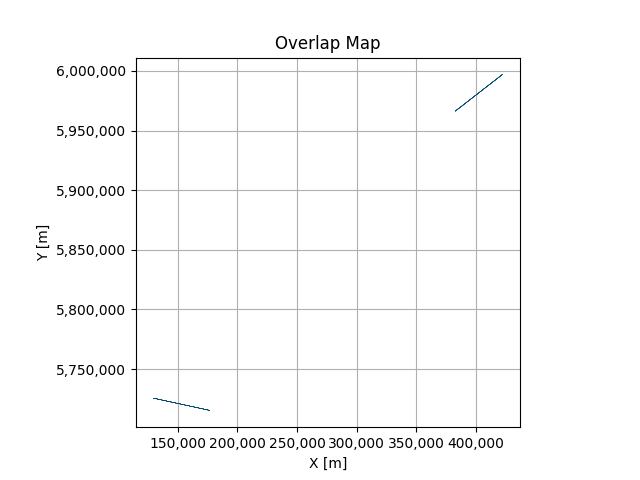

12 coincident lines found.


In [18]:
qc.checkOverlaps(d10h)

#### Aircraft speed
<div class="alert alert-block alert-success">
PASS
<div>

In [19]:
qc.checkSpeeds(d10h, nominalSpeed=60, maxLength=60)

Velocities not known - will calculate from positions
Nominal speed 60.0; allowed 54.0 : 66.0 for < 60.0 seconds.

8 lines had some short exceedance(s).
0 lines failed for exceedance > allowed distance.


#### Data gaps
<div class="alert alert-block alert-success">
Pass
<div>

In [20]:
qc.checkSpikes(d10h, fields=['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID', 'B56s-267_GRS80', 'EOTCOR', 'FA100s_GEOID',
                             'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID', 'FACOR_GRS80', 'FTIME', 'FX', 'FY', 'FZ', 'LAT',
                             'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z', 'STATCOR', 'TACOR', 'V_EAST', 'V_NORTH', 'YEAR'])

In [21]:
qc.checkGaps(d10h)

Checking for all gaps in all 38 channels on all 8 lines.

0 lines failed.


In [22]:
qc.checkConstantSlope(d10h, ['DOY', 'FLIGHT', 'FTIME', 'LINE', 'YEAR'])

All fields tested were either constant or of constant slope for all lines tested.


#### Check GNSS
<div class="alert alert-block alert-success">
Pass
<div>

In [23]:
qc.checkGNSS(d10h, 'NSATS', 'PDOP', 'VDOP', 'HDOP', nsats_min=4, max_pdop=6, 
                  max_hdop=4, max_vdop=4)

In Victoria and South Australia Gravity, checked num sats, PDOP, VDOP and HDOP. Found 0 errors.


#### Check filtering
<div class="alert alert-block alert-success">
PASS
<div>

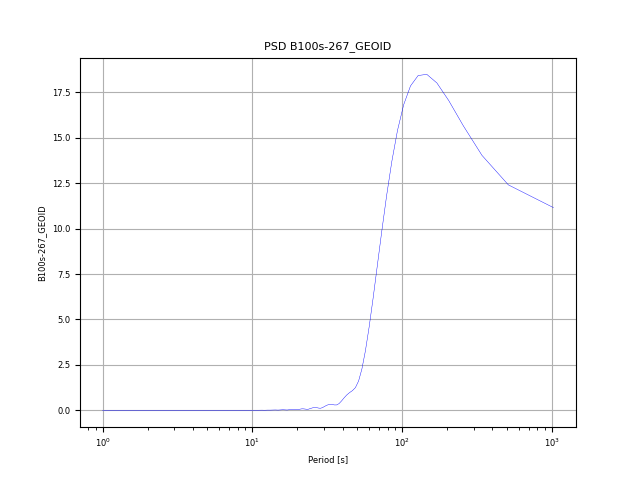

In [24]:
wp.psdLineChannel(d10h, '8001.0', 'B100s-267_GEOID', plotTitle='PSD B100s-267_GEOID')

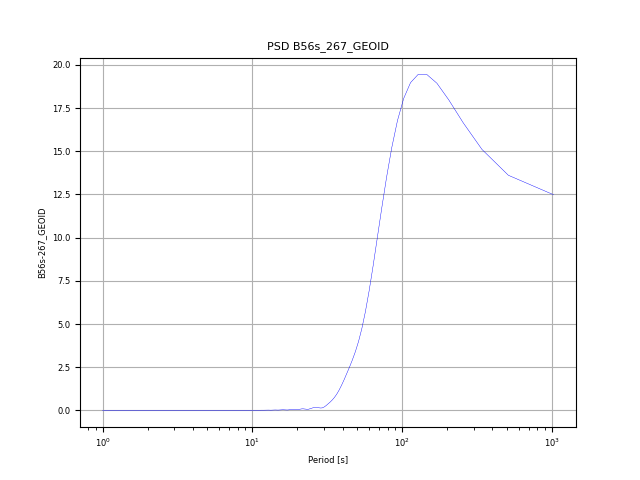

In [25]:
wp.psdLineChannel(d10h, '8001.0', 'B56s-267_GEOID', plotTitle='PSD B56s_267_GEOID')

The power spectra are at least consistent with the expected filtering.

#### Check all required deliverables present
<div class="alert alert-block alert-success">
PASS
<div>

The contract does not discriminate between field and final data but I am satisfied that all data required in field data has been delivered.

#### Atmospheric corrections
<div class="alert alert-block alert-success">
Atmospheric corrections: PASS
<div>

[For this and consequent checks, the result should be zero. The plots have a square at the mean, a vertical bar over a standard deviation,
and circles at the minimum and maximum.]

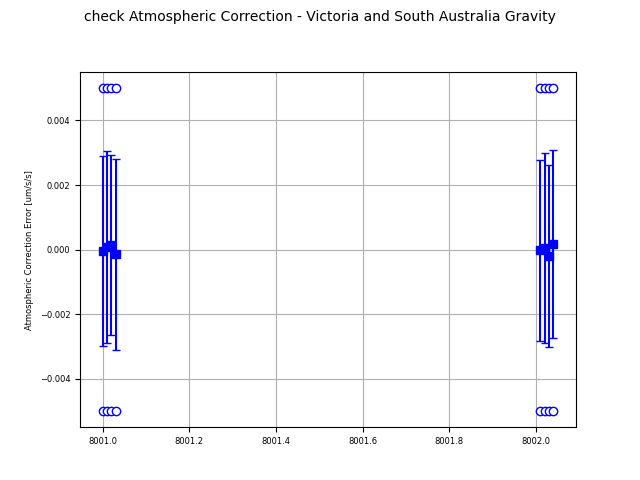

In [26]:
qc.checkAtmosEffect(d10h, 'ATMCOR', GRS80_height='MGA-Z')

#### Free air corrections
<div class="alert alert-block alert-success">
Free air corrections: PASS
<div>

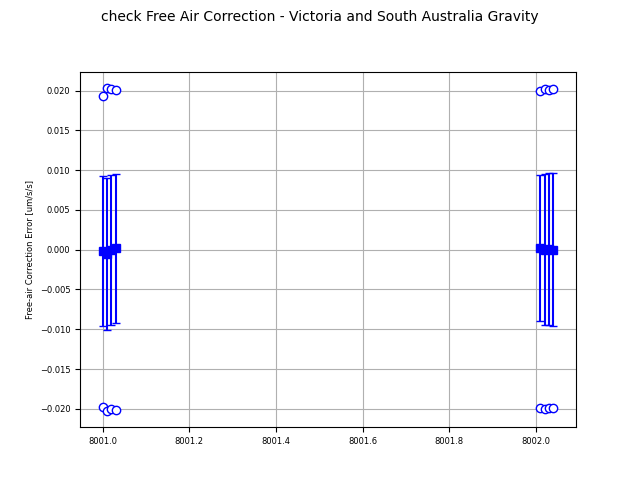

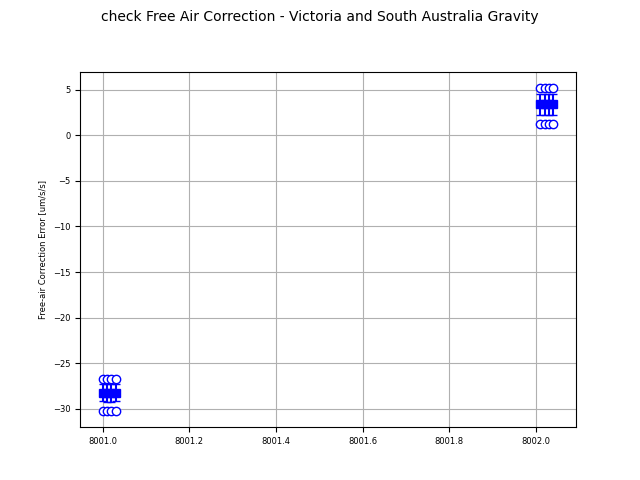

In [27]:
qc.checkFreeAirCorr(d10h, 'FACOR_GRS80')
qc.checkFreeAirCorr(d10h, 'FACOR_GEOID')

#### Eotvos corrections
<div class="alert alert-block alert-success">
Eotvos corrections: PASS
<div>

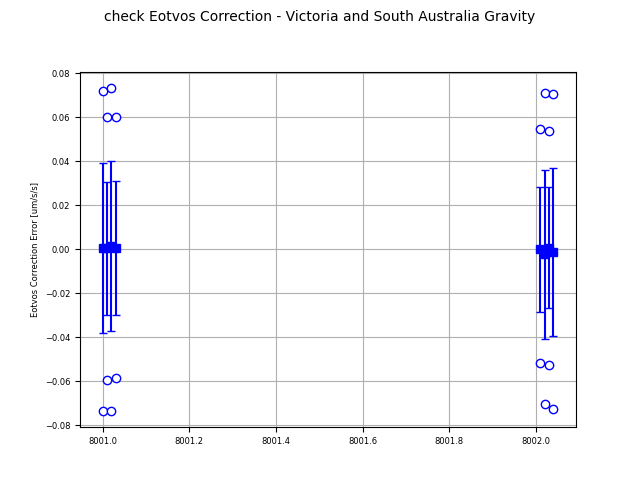

In [28]:
qc.checkEotvosCorr(d10h, 'EOTCOR', east_vel='V_EAST', north_vel='V_NORTH')

#### Latitude corrections (normal gravity)
<div class="alert alert-block alert-success">
Latitude corrections: PASS
<div>

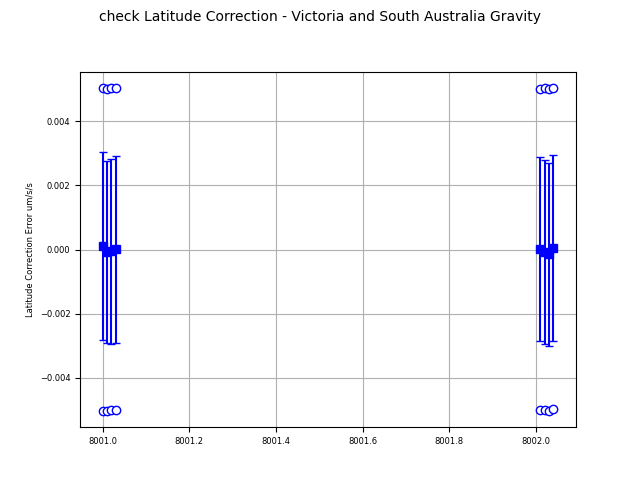

In [29]:
qc.checkLatCorr(d10h, 'LATCOR')

#### Aircraft acceleration
<div class="alert alert-block alert-success">
Aircraft acceleration: PASS
<div>

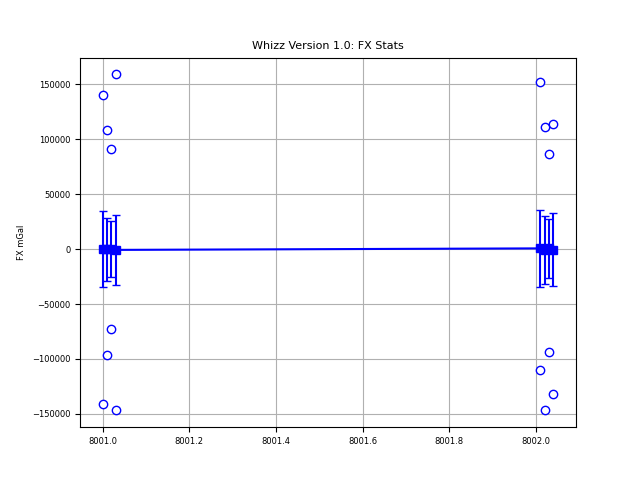

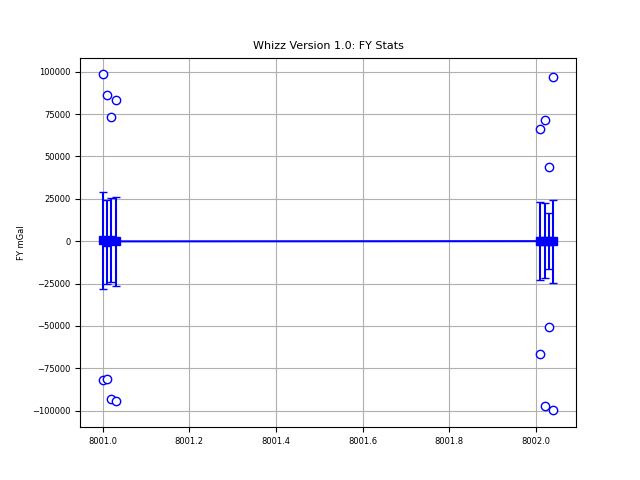

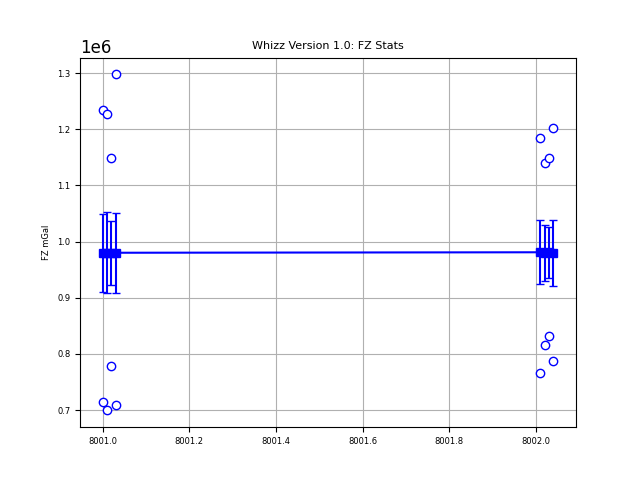

In [30]:
qc.allChanStats(d10h,allChannels=['FX', 'FY', 'FZ'])

Means and variances are typical for airborne geophysical surveys.